# Chapter 10 - Long-Term Tracking

## Goals

This chapter translates the original Bmad `long_term_tracking` workflow into the SciBmad/Julia ecosystem. In SciBmad, long-term tracking is performed directly with `track` or `track!`, and Julia code controls how the resulting particle or beam statistics are stored.

By the end of the chapter, we will:

1. initialize a multi-particle beam as an `n_particles × 6` coordinate matrix;
2. construct a compact storage-ring model and choose the number of turns and output interval;
3. save and visualize individual particle trajectories with `track`;
4. compute beam averages and rms emittances during streaming tracking with `track!`.

> **SciBmad translation.** Classic Bmad uses a separate `long_term_tracking` program and initialization file. SciBmad instead exposes tracking as Julia functions. This notebook uses a compact pedagogical ring so that both examples run quickly while still using real SciBmad multi-turn tracking.

In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [1]:
using SciBmad
using CairoMakie
using LinearAlgebra
using Statistics
using Random
using Printf

## 10.1 Initializing a Beam

SciBmad represents the phase-space coordinates of one particle as

$$
\mathbf v=(x,\;p_x,\;y,\;p_y,\;z,\;p_z).
$$

A beam is represented by a matrix with one particle per row and the six coordinates in columns. This replaces the ASCII or HDF5 beam-initialization file used by the original Bmad example.

The seven particles below reproduce the idea of the original Chapter 10 example: some particles begin with different longitudinal positions $z$, while others begin with different relative momenta $p_z$.

In [2]:
particle_v0 = zeros(7, 6)

# Particles 2 and 3 begin with nonzero longitudinal position.
particle_v0[:, 5] .= [0.0, 0.005, 0.010, 0.0, 0.0, 0.0, 0.0]

# Particles 4 through 7 begin with nonzero relative momentum.
particle_v0[:, 6] .= [0.0, 0.0, 0.0, 0.001, 0.002, 0.003, 0.004]

particle_v0

7×6 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0    0.0
 0.0  0.0  0.0  0.0  0.005  0.0
 0.0  0.0  0.0  0.0  0.01   0.0
 0.0  0.0  0.0  0.0  0.0    0.001
 0.0  0.0  0.0  0.0  0.0    0.002
 0.0  0.0  0.0  0.0  0.0    0.003
 0.0  0.0  0.0  0.0  0.0    0.004

When direct control of the current beam state is needed, the matrix can be wrapped in a mutable SciBmad `Bunch`:

```julia
bunch = Bunch(copy(particle_v0); species=ring.species_ref, p_over_q_ref=ring.p_over_q_ref)
track!(bunch, ring)
```

The exclamation mark indicates that `track!` updates `bunch` in place.

## 10.2 Initializing Long-Term Tracking

The original Bmad initialization file specifies a lattice, tracking method, number of turns, initial beam, and output settings. In SciBmad these become ordinary Julia objects and keyword arguments.

For this chapter we construct a compact 16-cell electron storage ring containing quadrupoles, bends, drifts, and one RF cavity. The model is intentionally small enough for interactive multi-turn examples.

In [3]:
function build_long_term_tracking_ring(; n_cells=16, rf_voltage=2.0e6)
    elements = SciBmad.LineElement[]

    for i in 1:n_cells
        push!(elements, Quadrupole(name="QF_$i", L=0.25, Kn1=0.8))
        push!(elements, Drift(name="D1_$i", L=0.40))
        push!(elements, SBend(name="B_$i", L=1.0, angle=2pi / n_cells))
        push!(elements, Drift(name="D2_$i", L=0.40))
        push!(elements, Quadrupole(name="QD_$i", L=0.25, Kn1=-0.8))
        push!(elements, Drift(name="D3_$i", L=0.40))

        if i == n_cells
            push!(elements, RFCavity(name="RF", L=0.01, harmon=32, voltage=rf_voltage))
        end
    end

    return Beamline(elements; species_ref=Species("electron"), E_ref=3e9)
end

ring = build_long_term_tracking_ring()

@printf("Ring elements: %d\n", length(ring.line))
@printf("Ring circumference: %.3f m\n", sum(element.L for element in ring.line))

Ring elements: 97
Ring circumference: 43.210 m


In [5]:
# These variables play the role of settings in long_term_tracking.init.
particle_n_turns = 30
particle_save_every = 1

average_n_turns = 400
average_save_every = 10

@printf("Particle trajectories: %d turns, save every %d turn(s)\n",
        particle_n_turns, particle_save_every)
@printf("Beam averages: %d turns, save every %d turn(s)\n",
        average_n_turns, average_save_every)

Particle trajectories: 30 turns, save every 1 turn(s)
Beam averages: 400 turns, save every 10 turn(s)


The two SciBmad interfaces serve different output strategies:

| Interface | Behavior | Best use |
|---|---|---|
| `track(ring, v0; n_turns, save_every_n_turns)` | Returns stored coordinates for every particle at every requested saved turn | Individual particle trajectories |
| `track!(bunch, ring)` | Advances the existing bunch and keeps only its current state | Streaming averages and very long runs |

## 10.3 Particle Track Output

Calling `track` stores the phase-space coordinates of every particle at the requested turn interval. With the SciBmad tracking API used here, the returned array is indexed as

```julia
history[particle, saved_turn, coordinate]
```

The first saved-turn index is the initial state at turn zero.

In [6]:
particle_history = track(
    ring,
    particle_v0;
    n_turns=particle_n_turns,
    save_every_n_turns=particle_save_every,
)

@printf("Stored array size = %s\n", string(size(particle_history)))
@printf("Interpretation: particles × saved turns × coordinates\n")

Stored array size = (7, 31, 6)
Interpretation: particles × saved turns × coordinates


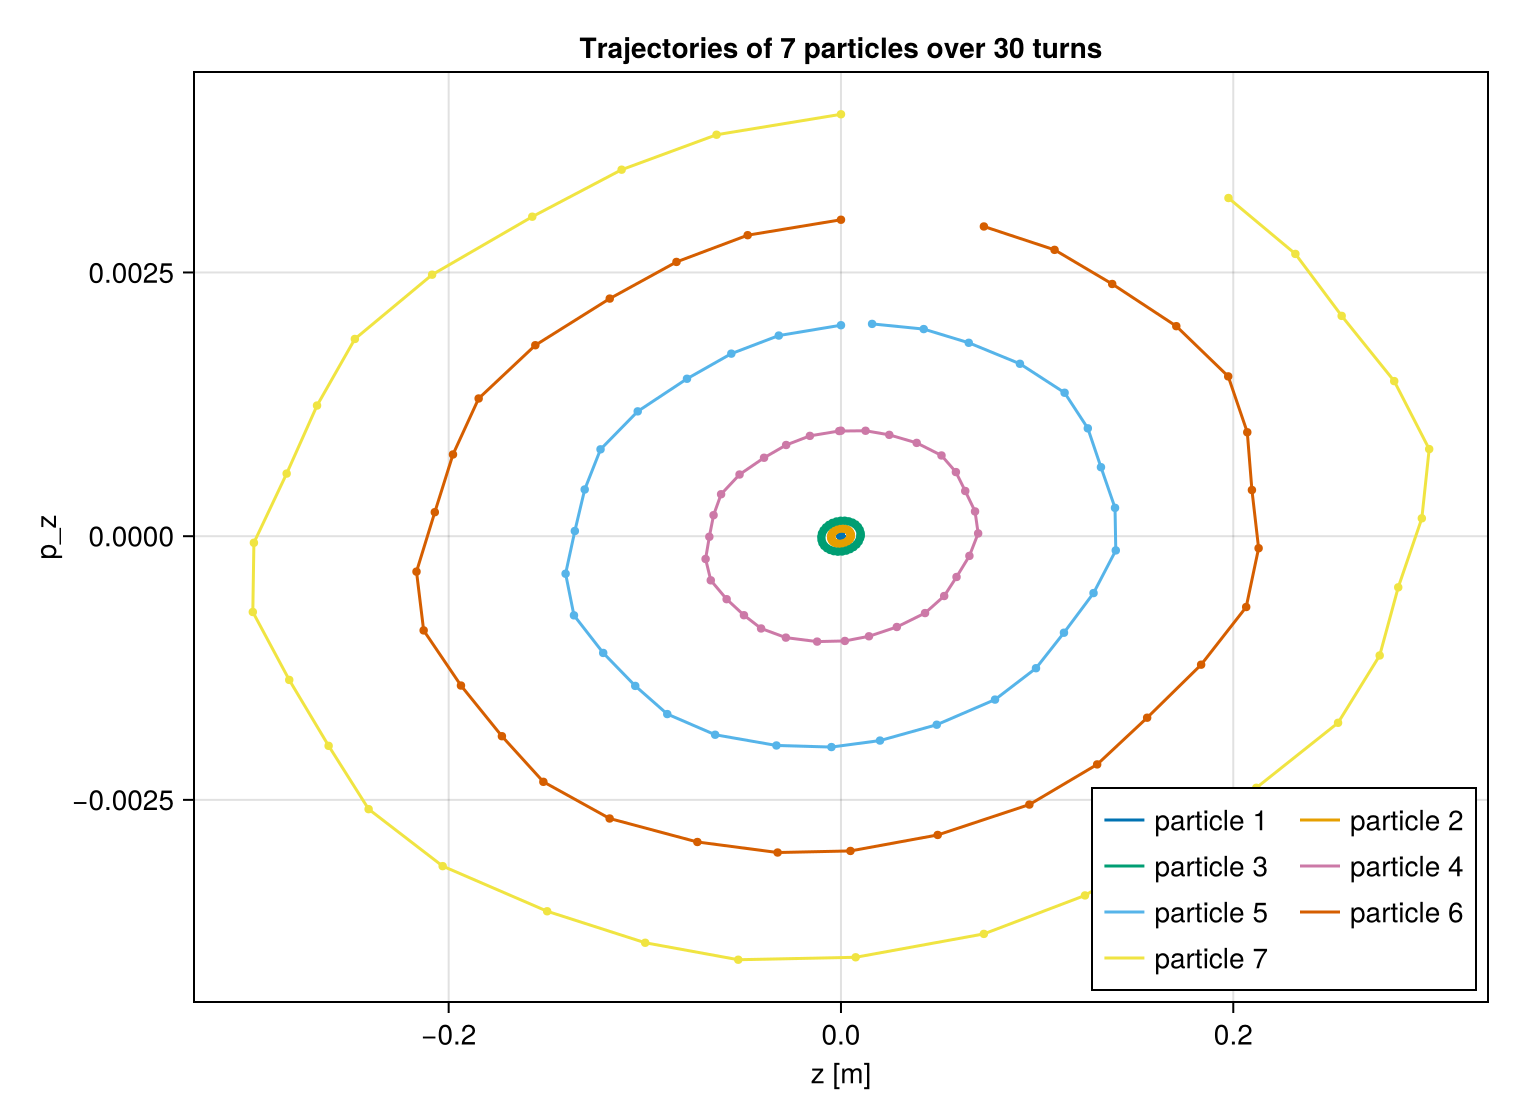

In [7]:
particle_figure = Figure(size=(760, 560))
particle_axis = Axis(
    particle_figure[1, 1];
    xlabel="z [m]",
    ylabel="p_z",
    title="Trajectories of 7 particles over 30 turns",
)

for particle in axes(particle_history, 1)
    lines!(
        particle_axis,
        particle_history[particle, :, 5],
        particle_history[particle, :, 6];
        linewidth=1.5,
        label="particle $particle",
    )
    scatter!(
        particle_axis,
        particle_history[particle, :, 5],
        particle_history[particle, :, 6];
        markersize=6,
    )
end

axislegend(particle_axis; position=:rb, nbanks=2)
particle_figure

This output is the SciBmad equivalent of the original `turn##` particle files. It contains enough information to inspect individual trajectories, phase-space islands, resonances, and particle loss. Its memory requirement grows approximately as

$$
N_{\mathrm{particles}}\times N_{\mathrm{saved\ turns}}\times 6.
$$

For many particles and many turns, storing every trajectory becomes expensive.

## 10.4 Averages Output

For long simulations, it is often better to retain only beam-level quantities. The original Bmad program can automatically write files such as `ave.dat`, `sigma.dat`, and `emit.dat`. SciBmad does not currently provide that exact file-output interface, so we implement the same idea directly in Julia:

1. hold the current particles in a mutable `Bunch`;
2. advance the bunch one turn with `track!`;
3. every requested interval, compute the beam centroid, covariance matrix, and rms emittances;
4. retain only those compact statistics.

The following beam begins as a Gaussian distribution in all three phase-space planes.

In [9]:
Random.seed!(10)

n_particles = 300
beam_v0 = zeros(n_particles, 6)
beam_v0[:, 1] .= 2e-3 .* randn(n_particles)
beam_v0[:, 2] .= 2e-4 .* randn(n_particles)
beam_v0[:, 3] .= 1e-3 .* randn(n_particles)
beam_v0[:, 4] .= 1e-4 .* randn(n_particles)
beam_v0[:, 5] .= 5e-3 .* randn(n_particles)
beam_v0[:, 6] .= 8e-4 .* randn(n_particles)

bunch = Bunch(copy(beam_v0); species=ring.species_ref, p_over_q_ref=ring.p_over_q_ref)

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -10.006922710777511, 0.0, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}(UInt8[0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01  …  0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01, 0x01], [0.002551055852713576 5.750350896788426e-6 … -0.008331403921736886 -3.526292531016881e-5; -0.0016473616904639945 3.288925398939903e-5 … 0.007436161898510981 -4.519370608430413e-5; … ; -0.001827096471276949 0.00023163773219952538 … -0.000628101179009496 0.00011860287547256341; -0.0005861876979465807 -0.00019225560848151413 … -0.008105632754003613 0.0008279649026527997], nothing, nothing))

In [10]:
function bunch_statistics(bunch)
    X = Array(bunch.coords.v)
    centroid = vec(mean(X; dims=1))
    sigma = cov(X)

    # Projected rms emittances. For a strongly coupled beam, normal-mode
    # emittances should instead be obtained from the full 6x6 sigma matrix.
    emit_x = sqrt(max(det(sigma[1:2, 1:2]), 0.0))
    emit_y = sqrt(max(det(sigma[3:4, 3:4]), 0.0))
    emit_z = sqrt(max(det(sigma[5:6, 5:6]), 0.0))

    return (; centroid, sigma, emit_x, emit_y, emit_z)
end

bunch_statistics (generic function with 1 method)

In [11]:
saved_turns = Int[]
centroid_history = Vector{Vector{Float64}}()
sigma_history = Matrix{Float64}[]
emit_x_history = Float64[]
emit_y_history = Float64[]
emit_z_history = Float64[]

for turn in 0:average_n_turns
    if turn % average_save_every == 0
        stats = bunch_statistics(bunch)
        push!(saved_turns, turn)
        push!(centroid_history, stats.centroid)
        push!(sigma_history, stats.sigma)
        push!(emit_x_history, stats.emit_x)
        push!(emit_y_history, stats.emit_y)
        push!(emit_z_history, stats.emit_z)
    end

    turn < average_n_turns && track!(bunch, ring)
end

@printf("Tracked %d particles for %d turns\n", n_particles, average_n_turns)
@printf("Retained only %d statistical snapshots\n", length(saved_turns))

Tracked 300 particles for 400 turns
Retained only 41 statistical snapshots


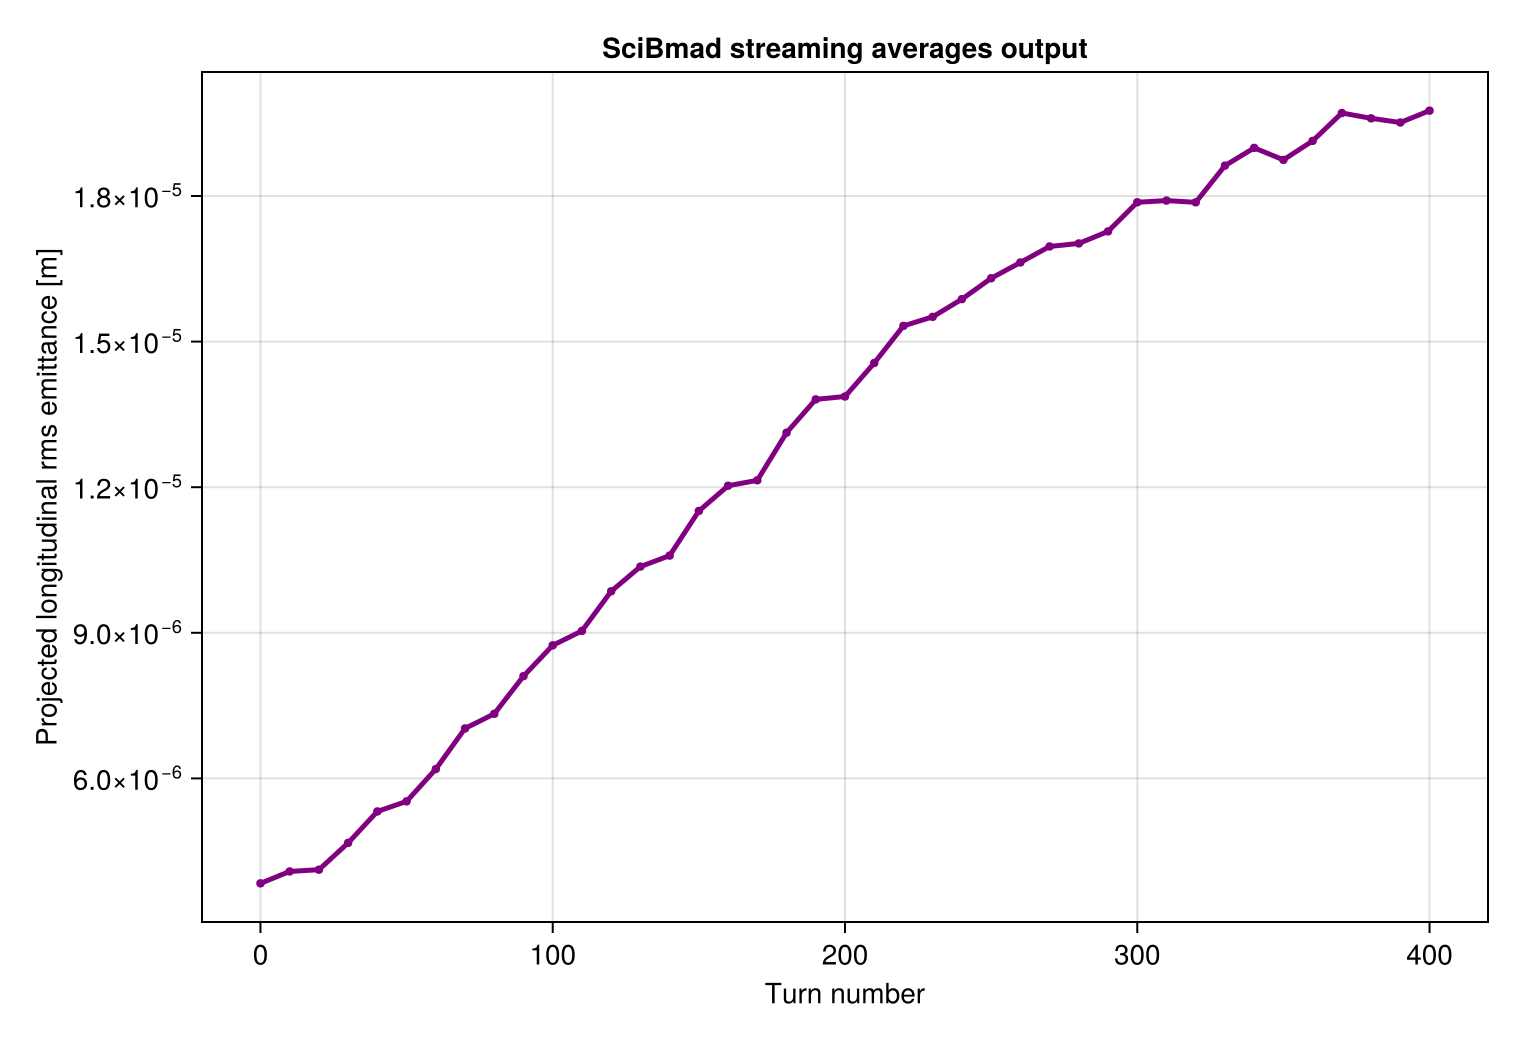

In [10]:
average_figure = Figure(size=(760, 520))
average_axis = Axis(
    average_figure[1, 1];
    xlabel="Turn number",
    ylabel="Projected longitudinal rms emittance [m]",
    title="SciBmad streaming averages output",
)

lines!(average_axis, saved_turns, emit_z_history; color=:purple, linewidth=2.5)
scatter!(average_axis, saved_turns, emit_z_history; color=:purple, markersize=6)

average_figure

The longitudinal projected rms emittance grows because the finite beam samples nonlinear longitudinal motion and phase-mixes. By turn 400 the growth rate has begun to slow, but the beam has not yet demonstrated a true equilibrium plateau. The curve should **not** be interpreted as the radiation-damping equilibrium shown in the original Bmad chapter: this compact SciBmad example does not enable radiation damping or quantum excitation.

The important output lesson is unchanged:

- `track` preserves individual particle histories and is ideal for detailed trajectory studies;
- repeated `track!` calls permit streaming analysis and keep memory use approximately proportional to the number of current particles, rather than the number of tracked turns.

The stored `centroid_history`, `sigma_history`, and emittance arrays are the SciBmad/Julia equivalents of averages-output files. They can be written with Julia packages such as `DelimitedFiles`, `CSV`, or `HDF5` when persistent files are required.

## 10.5 Exercises

1. **Initial parameters.** Experiment with different initial particle coordinates and plot their trajectories. Scan the initial $p_z$ over a wider range and determine approximately where the longitudinal motion stops remaining bounded. Track particles in the longitudinal $(z,p_z)$ phase space, and identify stable and unstable fixed points and invariant curves.

2. **50% core emittance.** The original Bmad exercise reads a `50% Core` emittance column from `emit.dat`. SciBmad does not currently generate that averages-output file automatically, so calculate a core-emittance estimate directly from the tracked particle coordinates. At each saved turn, use the longitudinal $(z,p_z)$ covariance matrix to rank particles by their quadratic distance from the bunch centroid, retain the closest 50% of particles, and calculate their projected rms emittance. Plot the full-beam and 50%-core emittances together. Then add a small number of large-amplitude particles to the initial beam and explain why the two emittance measures respond differently.

   The 50%-core construction in this exercise is a SciBmad/Julia implementation chosen for this tutorial; state the precise particle-selection rule you use when reporting the result.